In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import tsplib95
import matplotlib.pyplot as plt
import numpy as np
import random
from tsp_hillclimbing import calculate_distances, multi_start_hill_climbing, evaluate_function, hill_climbing

In [36]:
data_filepath = r"D:\PycharmProjects\University\HeuristicAlgorithms\data\pr76.tsp"
data_opt_filepath = r"D:\PycharmProjects\University\HeuristicAlgorithms\data\pr76.opt.tour"

problem = tsplib95.load(data_filepath)
opt = tsplib95.load(data_opt_filepath)

cities = list(problem.node_coords.values())
N = problem.dimension

distances = calculate_distances(cities, N)

In [37]:
best_route, best_score, all_scores = multi_start_hill_climbing(distances, 100)

In [38]:
worst_score = max(all_scores)
difference = worst_score - best_score
difference_percentage = (difference / worst_score) * 100

print(f"\nНайкращий знайдений маршрут: {best_score:.2f}")
print(f"Найгірший знайдений маршрут: {worst_score:.2f}")
print(f"Різниця між найгіршим і найкращим: {difference:.2f} ({difference_percentage:.2f}%)")


Найкращий знайдений маршрут: 115638.87
Найгірший знайдений маршрут: 162112.79
Різниця між найгіршим і найкращим: 46473.91 (28.67%)


In [39]:
opt_route = [node - 1 for node in opt.tours[0]]
opt_score = evaluate_function(opt_route, distances)
difference = best_score - opt_score
difference_percentage = (difference / opt_score) * 100

print(f"Оптимальний маршрут: {opt_score:.2f}")
print(f"Найкращий маршрут алгоритму: {best_score:.2f}")
print(f"Різниця між найкращим і оптимальним: {difference:.2f} ({difference_percentage:.2f}%)")

Оптимальний маршрут: 108159.44
Найкращий маршрут алгоритму: 115638.87
Різниця між найкращим і оптимальним: 7479.44 (6.92%)


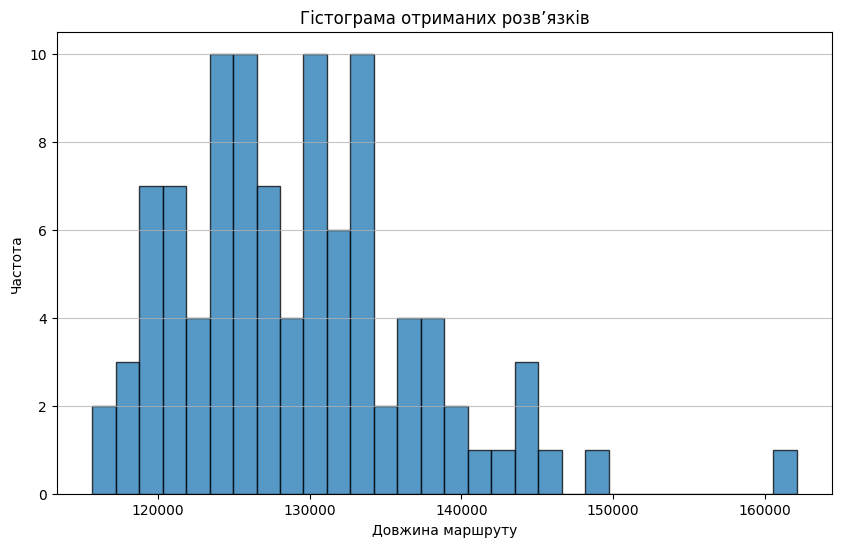

In [40]:
plt.figure(figsize=(10, 6))
plt.hist(all_scores, bins=30, edgecolor='black', alpha=0.75)
plt.title('Гістограма отриманих розв’язків')
plt.xlabel('Довжина маршруту')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

Аналіз побудованої гістограми показує розподіл довжин маршрутів, отриманих за 500 запусків алгоритму. Як видно з графіку, знайдені розв'язки мають значний розкид, а велика їх частина скупчується у гірших значеннях (в діапазоні 8500–9800). Це свідчить про те, що базовий алгоритм Hill Climbing дуже часто застрягає в локальних оптимумах, які суттєво гірші за глобальний. Лише окремі запуски здатні наблизитись до найкращого значення, що підтверджує необхідність використання підходу мультистарту для отримання якісного результату.

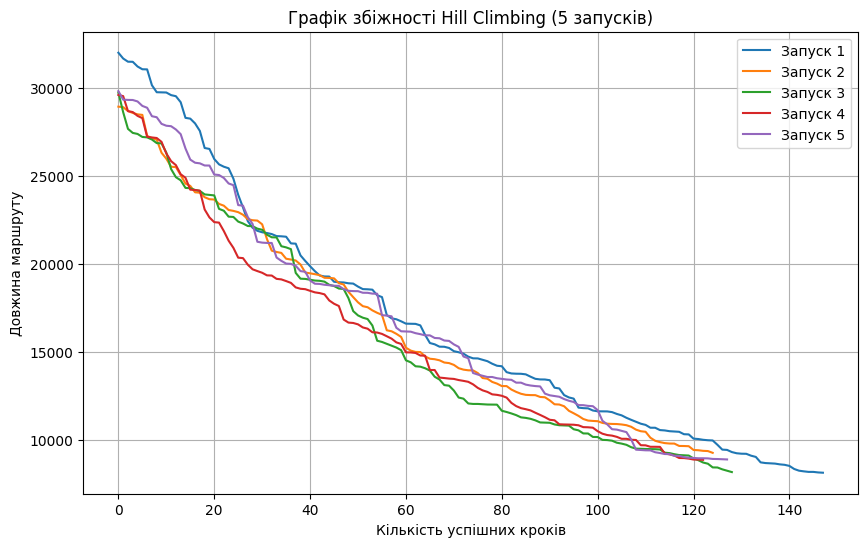

In [33]:
plt.figure(figsize=(10, 6))

for i in range(5):
    initial_route = list(range(N))
    random.shuffle(initial_route)

    _, _, history = hill_climbing(distances, initial_route)

    plt.plot(history, label=f'Запуск {i+1}')

plt.title('Графік збіжності Hill Climbing (5 запусків)')
plt.xlabel('Кількість успішних кроків')
plt.ylabel('Довжина маршруту')
plt.legend()
plt.grid(True)
plt.show()

Графік демонструє процес зменшення довжини маршруту для 5 різних запусків алгоритму з випадкових початкових станів. По осі абсцис відкладено кількість кроків, на яких було покращено результат, а по осі ординат - поточну довжину маршруту. Як видно з ліній, алгоритм достатньо швидко знаходить початкові покращення. Далі збіжність уповільнюється і кожен із запусків виходить на своє плато.

## Інформація про набори даних
- **Набір даних:** `berlin52.tsp`
- **Кількість міст:** 52
- **Оптимальна довжина маршруту:** 7544.37
- **Тип задачі:** Traveling Salesperson Problem.

## Умови обчислень
- **Алгоритм:** Hill Climbing з мультистартом.
- **Кількість перезапусків:** 500 кроків.
- **Генерація сусідів:** Розвертання випадкової підпослідовності у маршруті.
- **Критерій зупинки для одного сходження:** 500 кроків без покращення довжини маршруту.

## Отримані результати
- **Найкращий знайдений маршрут алгоритмом:** 7764.01
- **Найгірший знайдений маршрут:** 9884.86
- **Відхилення найкращого знайденого розв'язка від оптимуму:** 2.91%
- **Розкид значень:** Різниця між найгіршим і найкращим знайденим маршрутами становить 2120.85 одиниць (21.46%).